# 04 — O1 : immatriculations et permis

Ce notebook **visualise** les données qui alimentent les indicateurs de O1. Il ne produit aucun chiffre du 04 : la faisabilité vient de `faisabilite_indicateurs.csv` (`scripts/faisabilite_04.py`), les contrôles de `controles_coherence.csv` et `jointures.csv` (R-19). Aucune lecture causale.

**Ce qu'on regarde** : la série des immatriculations par catégorie (1990–2024), les permis par catégorie (2007–2024, sans 2013) et l'origine de la population de chaque année.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_04 import *
appliquer_style()
pd.set_option("display.max_colwidth", 90)

## Faisabilité des 9 indicateurs

In [2]:
display(faisabilite("O1"))

,Indicateur,Prévu (03),Résultat (04),Maille obtenue,Période,Preuve (04),Réserve
ID,,,,,,,
O1-01,Immatriculations par catégorie,Cible,Cible,National,1990–2024,A,
O1-02,Part de chaque catégorie,Cible,Cible,National,1990–2024,B,
O1-03,"Croissance annuelle, taux de croissance annuel moyen et multiplicateur",Cible,Cible,National,1990–2024,B,Ruptures de 1995 et 2004 à annoter
O1-04,Immatriculations pour 1 000 habitants,Cible,Cible,National,1990–2024,"B en 2010 et 2022, C les autres années",
O1-05,Parc estimé,Cible,Cible,National,2009–2024,C,
O1-06,Permis délivrés par catégorie,Cible,Cible,National,2007–2024 (sans 2013),A,Premières délivrances non prouvées (piège D2)
O1-07,Permis pour 1 000 habitants en âge de conduire,Cible,Cible,National,2007–2024 (sans 2013),C,
O1-08,Permis par sexe et tranche d’âge,Non,Non,—,,—,
O1-09,"Rapport immatriculations / permis, par catégorie",Cible,Cible,National,2007–2024 (sans 2013),B,Correspondance des catégories de véhicules et de permis à fixer au 06


## Immatriculations de l'année par catégorie

Le « parc immatriculé » du portail est un flux (contrôle 4.4-01). Les catégories : voitures ; motos (deux et trois-roues) ; poids lourds (camions, semi-remorques, tracteurs) ; autres (camionnettes, autocars).

In [3]:
# Immatriculations de l'année (un flux, contrôle 4.4-01) : portail jusqu'en 2022, annuaire 2024 ensuite
p = portail("parc_immatricule_par_type_1.csv").pivot(index="Date", columns="types-de-vehicule", values="Value")
a = annuaire("40.1").pivot(index="Année", columns="Ligne", values="Valeur")
a = a[a.index > p.index.max()]
somme = lambda df, cols: df[cols].sum(axis=1, min_count=len(cols))
imm = pd.concat([
    pd.DataFrame({"Motos (deux-roues et assimilés)": p["2 roues et assimilées"], "Voitures": p["Voitues"],
                  "Poids lourds": somme(p, ["Camions", "Semi-remorques", "Tracteurs"]), "Autres": somme(p, ["Camionnettes", "Autocars/Autobus"])}),
    pd.DataFrame({"Motos (deux-roues et assimilés)": somme(a, ["2 Roues", "3 Roues"]), "Voitures": a["Voiture"],
                  "Poids lourds": somme(a, ["Camions", "Semi-remorque", "Tracteur"]), "Autres": somme(a, ["Camionnette", "Autocar/Autobus"])}),
])
chrono = pd.read_csv(INTERIM.parent / "reference" / "chronologie_reformes.csv", dtype=str)
annees_chrono = sorted({int(d[:4]) for d in chrono["Date"]} & set(imm.index))

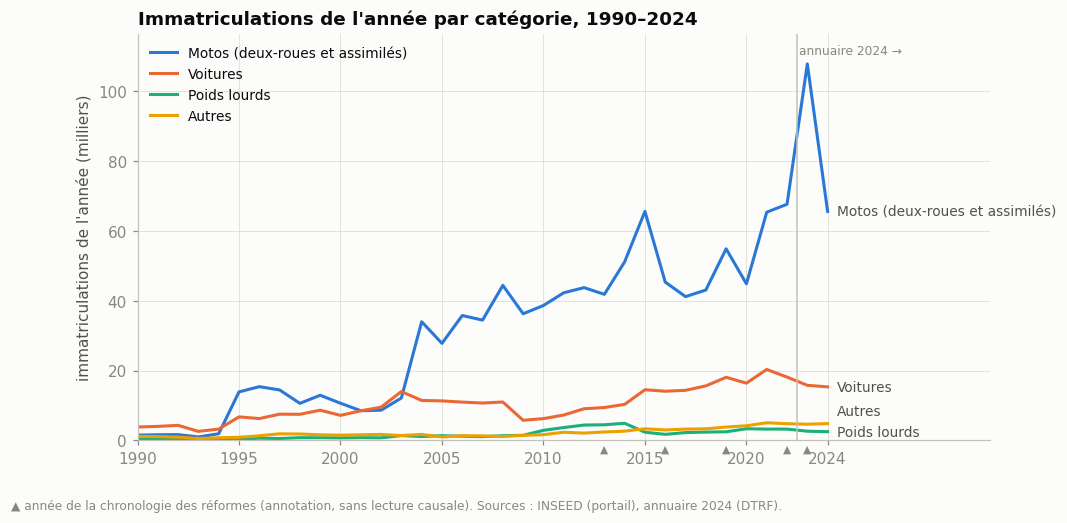

,Motos (deux-roues et assimilés),Voitures,Poids lourds,Autres
1990,1513,3814,337,1165
1991,1601,4004,381,1083
1992,1641,4300,386,923
1993,982,2577,252,538
1994,1887,3227,271,739
1995,13883,6728,357,868
1996,15383,6239,621,1312
1997,14445,7503,529,1878
1998,10603,7470,774,1822
1999,12917,8642,752,1592


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for couleur, cat in zip(SERIES, imm.columns):
    ax.plot(imm.index, imm[cat] / 1000, color=couleur, label=cat)
ax.set_ylim(0, imm.max().max() / 1000 * 1.08)
ax.axvline(2022.5, color=AXE, linewidth=1)
ax.annotate("annuaire 2024 →", (2022.6, ax.get_ylim()[1] * 0.95), fontsize=8, color=MUET)
for an in annees_chrono:
    ax.annotate("▲", (an, 0), xytext=(0, -2), textcoords="offset points", ha="center", va="top", fontsize=7, color=MUET)
ax.set_xlim(imm.index.min(), imm.index.max() + 8)
ax.set_xticks(list(range(1990, 2021, 5)) + [2024])
etiquettes_fin(ax, imm.index[-1], {cat: imm[cat].iloc[-1] / 1000 for cat in imm.columns})
ax.set_ylabel("immatriculations de l'année (milliers)")
ax.set_title("Immatriculations de l'année par catégorie, 1990–2024")
ax.legend(loc="upper left", fontsize=9)
fig.text(0.01, -0.02, "▲ année de la chronologie des réformes (annotation, sans lecture causale). Sources : INSEED (portail), annuaire 2024 (DTRF).", fontsize=8, color=MUET)
plt.show()
display(imm.astype("Int64"))

## Permis délivrés aux examens

2013 n'est pas publiée : le total y vaut 0 sans aucune catégorie. Elle reste vide sur le graphique, jamais à zéro (R-10, écart 14).

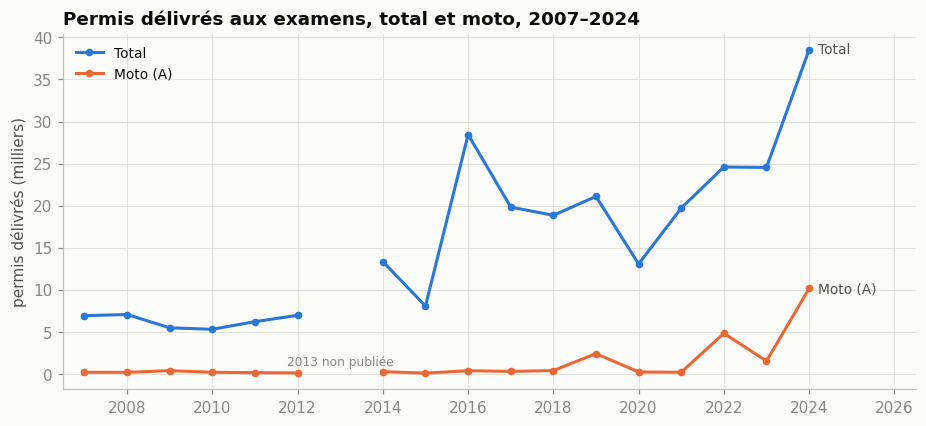

,Total,Moto (A)
2007,6931,205
2008,7069,198
2009,5488,398
2010,5313,206
2011,6225,157
2012,6969,129
2013,<NA>,<NA>
2014,13362,283
2015,8072,104
2016,28451,387


In [5]:
p = portail("permis_par_categorie.csv").pivot(index="Date", columns="categories-de-permis", values="Value")
p = p[p.drop(columns="Total").notna().all(axis=1)]
a = annuaire("40.4").pivot(index="Année", columns="Ligne", values="Valeur")
a = a[a.index > p.index.max()].rename(columns={"Moto": "Moto (A)"})
permis = pd.concat([p[["Total", "Moto (A)"]], a[["Total", "Moto (A)"]]]).reindex(range(2007, 2025))
fig, ax = plt.subplots(figsize=(10, 4.2))
for couleur, cat in zip(SERIES, ["Total", "Moto (A)"]):
    ax.plot(permis.index, permis[cat] / 1000, color=couleur, label=cat, marker="o", markersize=4)
ax.annotate("2013 non publiée", (2013, 1), ha="center", fontsize=8, color=MUET)
ax.set_xlim(2006.5, 2026.5); axe_annees(ax)
etiquettes_fin(ax, permis.index[-1], {cat: permis[cat].iloc[-1] / 1000 for cat in ["Total", "Moto (A)"]})
ax.set_ylabel("permis délivrés (milliers)")
ax.set_title("Permis délivrés aux examens, total et moto, 2007–2024")
ax.legend(loc="upper left", fontsize=9)
plt.show()
display(permis.astype("Int64"))

## Population de chaque année : origine et niveau de preuve

Recensements en 2010 et 2022 (A) ; projections de l'INSEED de 2011 à 2021 et après 2022 (C) ; avant 2010, taux de croissance de WPP (C). C'est ce qui place O1-04 en C hors 2010 et 2022.

In [6]:
origine = pd.DataFrame({"Année": range(1990, 2025)})
origine["Source"] = origine["Année"].map(lambda an: "recensement" if an in (2010, 2022) else ("WPP (taux de croissance)" if an < 2010 else "projection INSEED"))
origine["Preuve"] = origine["Source"].map({"recensement": "A"}).fillna("C")
display(origine.groupby(["Source", "Preuve"])["Année"].agg(["min", "max", "count"]))

,,min,max,count
Source,Preuve,,,
WPP (taux de croissance),C,1990,2009,20
projection INSEED,C,2011,2024,13
recensement,A,2010,2022,2
